In [11]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path.cwd().parent
DATA_PROCESSED = ROOT / "data" / "processed"

signals = pd.read_csv(DATA_PROCESSED / "regimes.csv", 
                      index_col=0, parse_dates=True)

print(f"Loaded: {signals.index[0].date()} → {signals.index[-1].date()}")
print(f"Rows: {len(signals)}")
print(signals[["vrp", "slope", "regime_label"]].head())

Loaded: 2006-08-29 → 2026-05-22
Rows: 4964
                 vrp     slope regime_label
date                                       
2006-08-29  0.003757  0.089577         calm
2006-08-30  0.006090  0.090016         calm
2006-08-31  0.007095  0.080422         calm
2006-09-01  0.006780  0.102843         calm
2006-09-05  0.010353  0.057799         calm


In [12]:
regime_multiplier = {
    "calm":     1.0,   # Full size
    "stressed": 0.5,   # Half size
    "crisis":   0.0    # Flat — no position
}
# Map each multiplier to each label
signals["regime_mult"] = signals["regime_label"].map(regime_multiplier)

In [13]:
# Normalise VRP to [0, 1] range using rolling 252-day percentile rank
# This tells us: is today's VRP large or small relative to recent history?
signals["vrp_rank"] = signals["vrp"].rolling(252).rank(pct=True)

# Only use positive VRP for sizing — we don't size into negative VRP
signals["vrp_rank"] = signals["vrp_rank"].clip(lower=0)

print(f"VRP rank mean: {signals['vrp_rank'].mean():.4f}")
print(f"VRP rank std:  {signals['vrp_rank'].std():.4f}")

VRP rank mean: 0.4976
VRP rank std:  0.2985


In [14]:
# position: signal strength × regime multiplier
# Capped at 1.0 (100% of max allocated capital)
signals["position"] = (signals["vrp_rank"] * signals["regime_mult"]).clip(0, 1)


# Drop warmup period from rolling rank
signals = signals.dropna(subset=["position"])

print(f"\nPosition statistics:")
print(f"  Mean:    {signals['position'].mean():.4f}")
print(f"  Max:     {signals['position'].max():.4f}")
print(f"  % days flat (crisis): {(signals['position'] == 0).mean()*100:.1f}%")


Position statistics:
  Mean:    0.3783
  Max:     1.0000
  % days flat (crisis): 11.6%


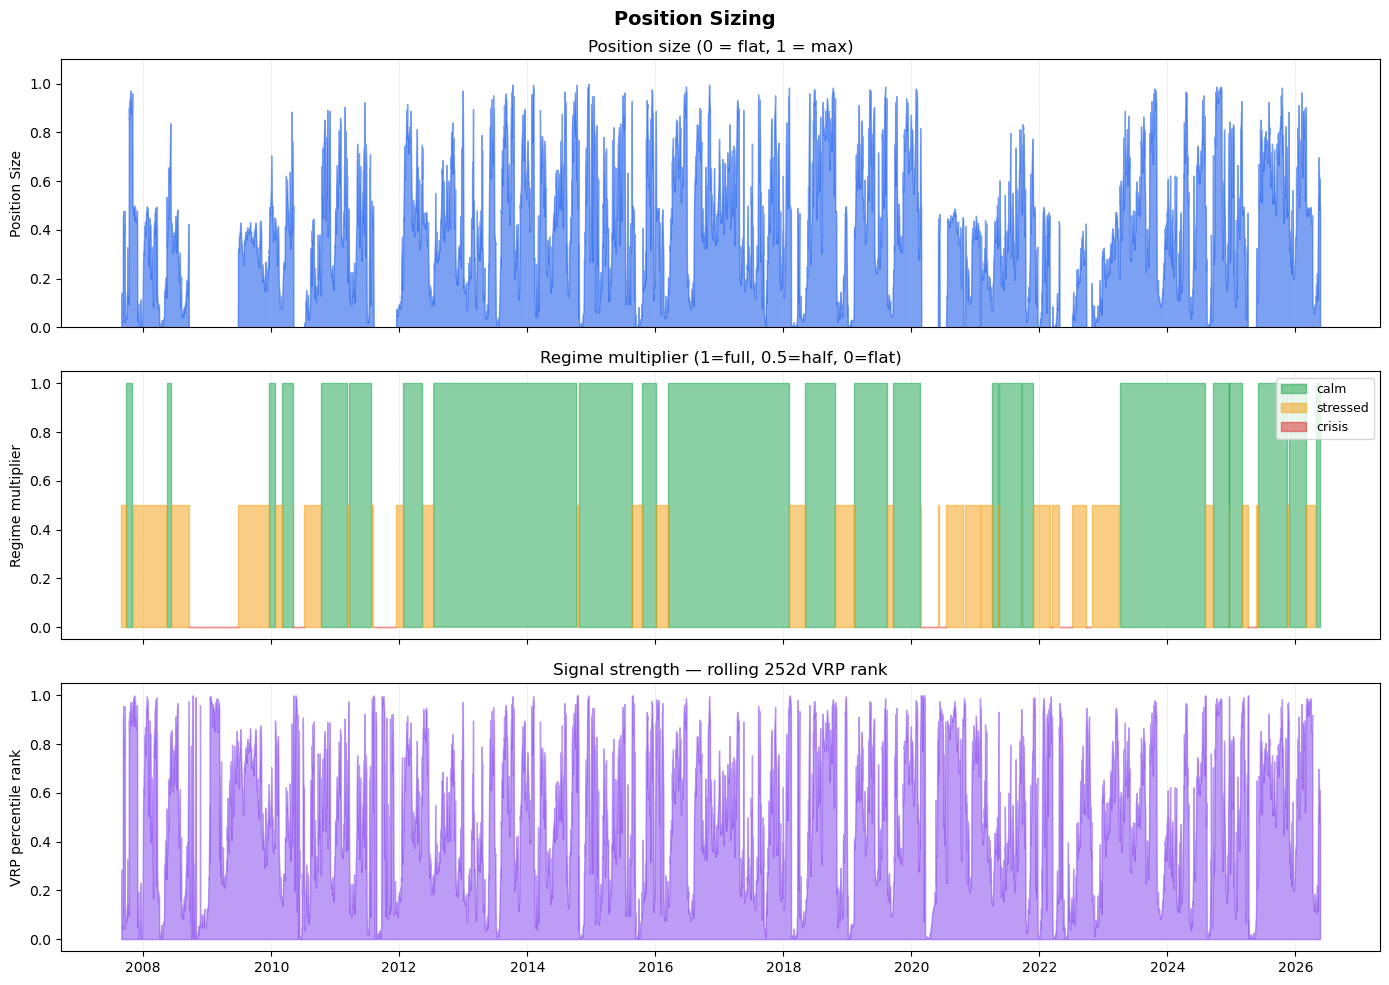

Saved positions.csv


In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Position Sizing", fontsize=14, fontweight="bold")

colors = {"calm": "#16a34a", "stressed": "#f59e0b", "crisis": "#dc2626"}

# Panel 1: Position size over time
axes[0].fill_between(signals.index, signals["position"], 
                     color="#2563eb", alpha=0.6)
axes[0].set_ylabel("Position Size")
axes[0].set_title("Position size (0 = flat, 1 = max)")
axes[0].set_ylim(0, 1.1)

# Panel 2: Regime multiplier
for label, color in colors.items():
    mask = signals["regime_label"] == label
    axes[1].fill_between(signals.index, signals["regime_mult"],
                         where=mask, color=color, alpha=0.5, label=label)
axes[1].set_ylabel("Regime multiplier")
axes[1].set_title("Regime multiplier (1=full, 0.5=half, 0=flat)")
axes[1].legend(loc="upper right", fontsize=9)

# Panel 3: VRP rank (signal strength)
axes[2].fill_between(signals.index, signals["vrp_rank"],
                     color="#7c3aed", alpha=0.5)
axes[2].set_ylabel("VRP percentile rank")
axes[2].set_title("Signal strength — rolling 252d VRP rank")

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(axis="x", linestyle="--", linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "position_sizing.png", dpi=150, bbox_inches="tight")
plt.show()

signals.to_csv(DATA_PROCESSED / "positions.csv")
print("Saved positions.csv")